In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib widget

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from geodesiq import Hamiltonian

In [3]:
def H_fun(x, z):
    return np.array([[z, x], [x, -z]])


def H_partial(x, z):
    return np.array([[1, 0], [0, -1]])


alpha = 20
beta = 20
x = 1
z0 = -10
zf = -z0

hamiltonian = Hamiltonian(H_fun, H_partial)
hamiltonian.set_parameters(x=x)
hamiltonian.set_control(control_name='z', pulse_initial=z0, pulse_final=zf, initial_state=0, alpha=alpha, beta=beta)
hamiltonian.solve_problem(pulse_accuracy=int(1e6))

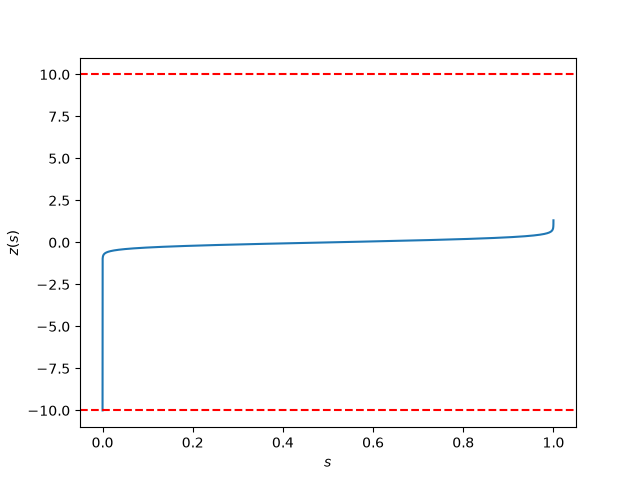

In [4]:
s, pulse = hamiltonian._s, hamiltonian.control_sol

fig, ax = plt.subplots()
ax.plot(s, pulse)

ax.axhline(z0, c='r', ls='--')
ax.axhline(zf, c='r', ls='--')

ax.set_xlabel(r'$s$')
ax.set_ylabel(r'$z(s)$');